<a href="https://colab.research.google.com/github/SayooJSimon/Labs/blob/main/LogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes

In [3]:
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target
y_binary = (y>np.median(y)).astype(int)

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42)

In [5]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [8]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
model.score(X_test, y_test)

0.7303370786516854

In [10]:
from sklearn.metrics import accuracy_score, classification_report
print(classification_report(y_test, y_pred))
acc = accuracy_score(y_test, y_pred)
print(acc)

              precision    recall  f1-score   support

           0       0.77      0.73      0.75        49
           1       0.69      0.72      0.71        40

    accuracy                           0.73        89
   macro avg       0.73      0.73      0.73        89
weighted avg       0.73      0.73      0.73        89

0.7303370786516854


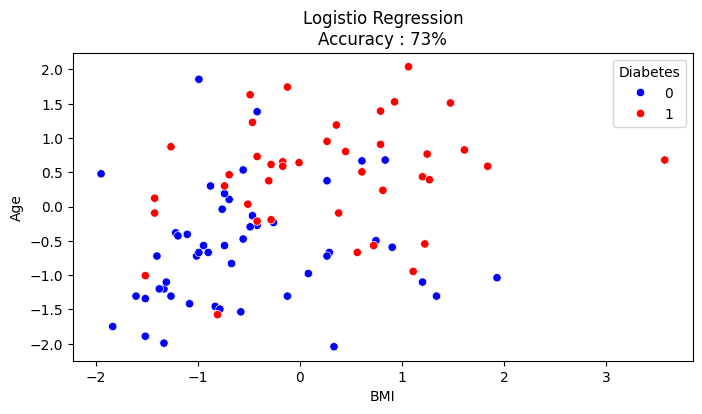

In [27]:
plt.figure(figsize=(8,4))
sns.scatterplot(x=X_test[:,2], y=X_test[:,8], hue = y_test, palette={0:'blue', 1:'red'}, marker='o')
plt.xlabel('BMI')
plt.ylabel('Age')
plt.title(f'Logistio Regression\nAccuracy : {acc*100:.0f}%')
plt.legend(title='Diabetes')
plt.show()